# Task 1: Conditional GAN on Fashion-MNIST

This notebook implements a compact Conditional GAN (cGAN) for Fashion-MNIST. It reads the local IDX files directly, conditions both networks on class labels, trains on a deterministic balanced selection of the training set, and saves the required figures.


In [21]:
import gzip
import math
import os
import random
import struct
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_num_threads(min(4, os.cpu_count() or 1))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

LATENT_DIM = 100
LABEL_EMBED_DIM = 50
BATCH_SIZE = 128
NUM_EPOCHS = 30
LEARNING_RATE = 2e-4
BETAS = (0.5, 0.999)
SAMPLES_PER_CLASS = 6000  # 6000 uses the full Fashion-MNIST training set; 3000 would use 50%.
NUM_CLASSES = 10

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(f"Using device: {DEVICE}")
print(f"Training config: epochs={NUM_EPOCHS}, batch_size={BATCH_SIZE}, latent_dim={LATENT_DIM}, lr={LEARNING_RATE}")


Using device: cpu
Training config: epochs=30, batch_size=128, latent_dim=100, lr=0.0002


## Dataset Inspection and Loading

The prompt names `data/FashionnMNIST`, while this workspace contains `data/FashionMNIST`. The resolver below checks both names and then reads the raw IDX files.


In [22]:
def resolve_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    data_root = Path("data")
    if data_root.exists():
        lower_map = {p.name.lower(): p for p in data_root.iterdir() if p.is_dir()}
        for candidate in candidates:
            key = Path(candidate).name.lower()
            if key in lower_map:
                return lower_map[key]
    raise FileNotFoundError(f"None of these dataset paths exist: {candidates}")


def summarize_tree(root, max_files_per_dir=8):
    root = Path(root)
    print(f"Dataset root: {root.resolve()}")
    for directory in [root] + sorted([p for p in root.rglob("*") if p.is_dir()]):
        files = sorted([p.name for p in directory.iterdir() if p.is_file()])
        rel = directory.relative_to(root) if directory != root else Path(".")
        print(f"{rel}: {len(files)} files")
        for name in files[:max_files_per_dir]:
            print(f"  - {name}")
        if len(files) > max_files_per_dir:
            print(f"  ... {len(files) - max_files_per_dir} more files")


fashion_root = resolve_existing_path([
    "data/FashionnMNIST",
    "data/FashionMNIST",
    "data/fashionmnist",
])
summarize_tree(fashion_root)


def open_idx_file(path):
    return gzip.open(path, "rb") if path.suffix == ".gz" else open(path, "rb")


def find_idx_file(raw_dir, names):
    for name in names:
        path = raw_dir / name
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find any of {names} in {raw_dir}")


def read_idx_images(path):
    with open_idx_file(path) as f:
        magic, count, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number {magic} in {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(count, rows, cols)
    return data


def read_idx_labels(path):
    with open_idx_file(path) as f:
        magic, count = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number {magic} in {path}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


raw_dir = fashion_root / "raw"
train_images_path = find_idx_file(raw_dir, ["train-images-idx3-ubyte", "train-images-idx3-ubyte.gz"])
train_labels_path = find_idx_file(raw_dir, ["train-labels-idx1-ubyte", "train-labels-idx1-ubyte.gz"])

images = read_idx_images(train_images_path)
labels = read_idx_labels(train_labels_path)
print(f"Loaded Fashion-MNIST train images: {images.shape}")
print(f"Loaded Fashion-MNIST train labels: {labels.shape}")
print("Full class distribution:", dict(zip(CLASS_NAMES, np.bincount(labels, minlength=NUM_CLASSES).tolist())))


Dataset root: C:\Users\Mana\OneDrive\Desktop\CE\Masters\Term 2\NN & DL\HW\3\code\data\FashionMNIST
.: 0 files
raw: 8 files
  - t10k-images-idx3-ubyte
  - t10k-images-idx3-ubyte.gz
  - t10k-labels-idx1-ubyte
  - t10k-labels-idx1-ubyte.gz
  - train-images-idx3-ubyte
  - train-images-idx3-ubyte.gz
  - train-labels-idx1-ubyte
  - train-labels-idx1-ubyte.gz
Loaded Fashion-MNIST train images: (60000, 28, 28)
Loaded Fashion-MNIST train labels: (60000,)
Full class distribution: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}


In [23]:
class FashionMNISTTensorDataset(Dataset):
    def __init__(self, images, labels, indices):
        self.images = images[indices]
        self.labels = labels[indices].astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx].astype(np.float32)).unsqueeze(0)
        image = image / 127.5 - 1.0
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


rng = np.random.default_rng(SEED)
subset_indices = []
for class_id in range(NUM_CLASSES):
    class_indices = np.where(labels == class_id)[0]
    rng.shuffle(class_indices)
    selected_count = min(SAMPLES_PER_CLASS, len(class_indices))
    subset_indices.extend(class_indices[:selected_count].tolist())
subset_indices = np.array(subset_indices)
rng.shuffle(subset_indices)

train_dataset = FashionMNISTTensorDataset(images, labels, subset_indices)
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
    generator=loader_generator,
)

subset_distribution = np.bincount(labels[subset_indices], minlength=NUM_CLASSES)
print(f"Using {len(train_dataset)} of {len(images)} training samples ({100 * len(train_dataset) / len(images):.1f}%).")
print("Selected class distribution:", dict(zip(CLASS_NAMES, subset_distribution.tolist())))
if len(train_dataset) == len(images):
    print("The full Fashion-MNIST training set is used.")
else:
    print("A deterministic balanced subset is used; increase SAMPLES_PER_CLASS to use more data.")


Using 60000 of 60000 training samples (100.0%).
Selected class distribution: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
The full Fashion-MNIST training set is used.


## Model Definition

The generator receives random noise and a label embedding. The discriminator receives the flattened image and a label embedding, and returns a real/fake logit.


In [24]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, label_embed_dim):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, label_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + label_embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        label_features = self.label_embedding(labels)
        x = torch.cat([noise, label_features], dim=1)
        return self.net(x).view(-1, 1, 28, 28)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes, label_embed_dim):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, label_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(28 * 28 + label_embed_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, images, labels):
        flat_images = images.view(images.size(0), -1)
        label_features = self.label_embedding(labels)
        x = torch.cat([flat_images, label_features], dim=1)
        return self.net(x).squeeze(1)


generator = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, LABEL_EMBED_DIM).to(DEVICE)
discriminator = ConditionalDiscriminator(NUM_CLASSES, LABEL_EMBED_DIM).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)

print(generator)
print(discriminator)


ConditionalGenerator(
  (label_embedding): Embedding(10, 50)
  (net): Sequential(
    (0): Linear(in_features=150, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
ConditionalDiscriminator(
  (label_embedding): Embedding(10, 50)
  (net): Sequential(
    (0): Linear(in_features=834, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropo

## Training

The discriminator is trained on real labeled images and fake labeled images. The generator is trained to make fake labeled images receive real logits from the discriminator.


In [25]:
def to_display_range(images):
    return ((images.detach().cpu().clamp(-1, 1) + 1.0) / 2.0).numpy()


def save_cgan_class_grid(model, path, samples_per_class=8):
    model.eval()
    all_images = []
    with torch.no_grad():
        for class_id in range(NUM_CLASSES):
            z = torch.randn(samples_per_class, LATENT_DIM, device=DEVICE)
            y = torch.full((samples_per_class,), class_id, dtype=torch.long, device=DEVICE)
            all_images.append(model(z, y))
    rows = [to_display_range(row) for row in all_images]
    fig, axes = plt.subplots(NUM_CLASSES, samples_per_class, figsize=(1.45 * samples_per_class, 14))
    for class_id in range(NUM_CLASSES):
        for sample_id in range(samples_per_class):
            ax = axes[class_id, sample_id]
            ax.imshow(rows[class_id][sample_id, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if sample_id == 0:
                ax.set_ylabel(CLASS_NAMES[class_id], fontsize=8)
    fig.suptitle("Final cGAN samples by conditioning class", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


def save_loss_curve(g_losses, d_losses, path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(g_losses) + 1), g_losses, marker="o", label="Generator")
    ax.plot(range(1, len(d_losses) + 1), d_losses, marker="s", label="Discriminator")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCEWithLogits loss")
    ax.set_title("cGAN training losses")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


fixed_progress_noise = torch.randn(NUM_CLASSES, LATENT_DIM, device=DEVICE)
fixed_progress_labels = torch.arange(NUM_CLASSES, dtype=torch.long, device=DEVICE)


def make_progress_snapshot(model):
    model.eval()
    with torch.no_grad():
        return model(fixed_progress_noise, fixed_progress_labels).detach().cpu()


def save_progress_grid(snapshots, path):
    ordered = sorted(snapshots.items())
    fig, axes = plt.subplots(len(ordered), NUM_CLASSES, figsize=(13, 1.5 * len(ordered)))
    if len(ordered) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_id, (epoch, tensor_images) in enumerate(ordered):
        display_images = to_display_range(tensor_images)
        for class_id in range(NUM_CLASSES):
            ax = axes[row_id, class_id]
            ax.imshow(display_images[class_id, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if row_id == 0:
                ax.set_title(CLASS_NAMES[class_id], fontsize=7)
            if class_id == 0:
                ax.set_ylabel(f"Epoch {epoch}", fontsize=9)
    fig.suptitle("Generated samples at early, middle, and final training stages", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


In [26]:
g_epoch_losses = []
d_epoch_losses = []
generated_snapshots = {}
snapshot_epochs = {1, max(1, (NUM_EPOCHS + 1) // 2), NUM_EPOCHS}

start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    generator.train()
    discriminator.train()
    running_g = 0.0
    running_d = 0.0
    batches = 0

    for real_images, real_labels in train_loader:
        real_images = real_images.to(DEVICE)
        real_labels = real_labels.to(DEVICE)
        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, device=DEVICE)
        fake_targets = torch.zeros(batch_size, device=DEVICE)

        optimizer_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real_images, real_labels)
        d_real_loss = criterion(real_logits, real_targets)

        z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        fake_labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=DEVICE)
        fake_images = generator(z, fake_labels)
        fake_logits = discriminator(fake_images.detach(), fake_labels)
        d_fake_loss = criterion(fake_logits, fake_targets)

        d_loss = 0.5 * (d_real_loss + d_fake_loss)
        d_loss.backward()
        optimizer_d.step()

        optimizer_g.zero_grad(set_to_none=True)
        z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=DEVICE)
        gen_images = generator(z, gen_labels)
        gen_logits = discriminator(gen_images, gen_labels)
        g_loss = criterion(gen_logits, real_targets)
        g_loss.backward()
        optimizer_g.step()

        running_d += d_loss.item()
        running_g += g_loss.item()
        batches += 1

    avg_d = running_d / batches
    avg_g = running_g / batches
    d_epoch_losses.append(avg_d)
    g_epoch_losses.append(avg_g)

    if epoch in snapshot_epochs:
        generated_snapshots[epoch] = make_progress_snapshot(generator)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | D loss: {avg_d:.4f} | G loss: {avg_g:.4f}")

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f} seconds.")


Epoch 01/30 | D loss: 0.6026 | G loss: 1.1271
Epoch 02/30 | D loss: 0.5881 | G loss: 1.2443
Epoch 03/30 | D loss: 0.5695 | G loss: 1.3016
Epoch 04/30 | D loss: 0.5645 | G loss: 1.3158
Epoch 05/30 | D loss: 0.5680 | G loss: 1.2971
Epoch 06/30 | D loss: 0.5816 | G loss: 1.2387
Epoch 07/30 | D loss: 0.5944 | G loss: 1.1534
Epoch 08/30 | D loss: 0.5937 | G loss: 1.1439
Epoch 09/30 | D loss: 0.6057 | G loss: 1.1156
Epoch 10/30 | D loss: 0.6184 | G loss: 1.0321
Epoch 11/30 | D loss: 0.6428 | G loss: 0.9269
Epoch 12/30 | D loss: 0.6505 | G loss: 0.8974
Epoch 13/30 | D loss: 0.6538 | G loss: 0.8944
Epoch 14/30 | D loss: 0.6613 | G loss: 0.8674
Epoch 15/30 | D loss: 0.6596 | G loss: 0.8581
Epoch 16/30 | D loss: 0.6665 | G loss: 0.8376
Epoch 17/30 | D loss: 0.6639 | G loss: 0.8484
Epoch 18/30 | D loss: 0.6666 | G loss: 0.8424
Epoch 19/30 | D loss: 0.6676 | G loss: 0.8229
Epoch 20/30 | D loss: 0.6664 | G loss: 0.8316
Epoch 21/30 | D loss: 0.6689 | G loss: 0.8163
Epoch 22/30 | D loss: 0.6673 | G l

## Results and Saved Figures


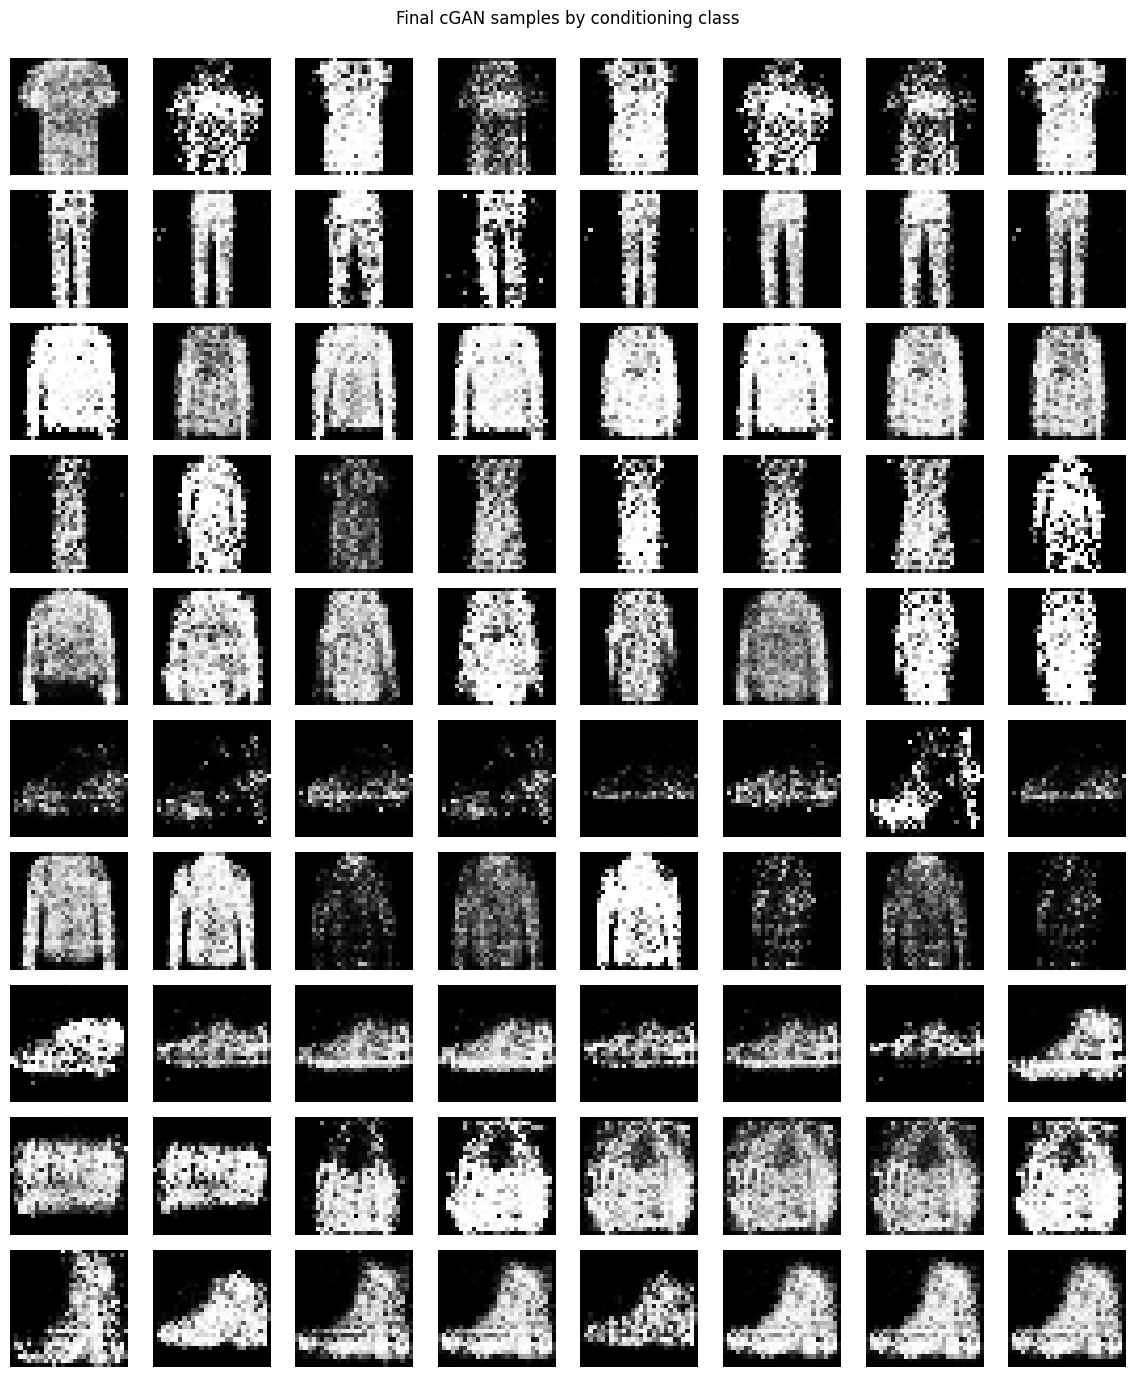

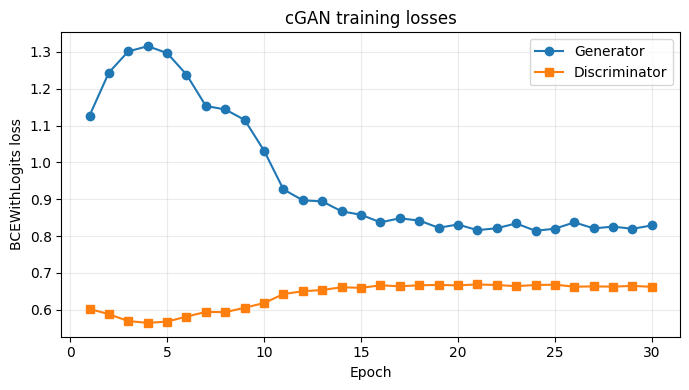

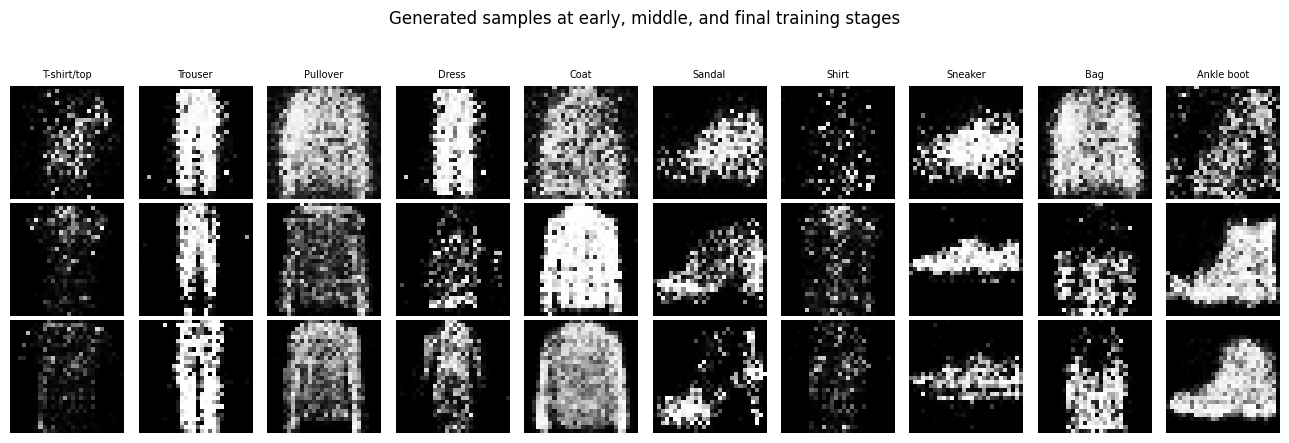

Saved final generated grid to figures\cgan_generated_grid_final.png
Saved cGAN loss curve to figures\cgan_loss_curve.png
Saved training progress grid to figures\cgan_training_progress.png


{'dataset_root': 'data\\FashionMNIST',
 'total_train_samples': 60000,
 'used_train_samples': 60000,
 'subset_percent': 100.0,
 'samples_per_class': 6000,
 'class_names': ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 'latent_dim': 100,
 'label_embed_dim': 50,
 'batch_size': 128,
 'epochs': 30,
 'learning_rate': 0.0002,
 'betas': [0.5, 0.999],
 'optimizer': 'Adam',
 'loss': 'BCEWithLogitsLoss',
 'generator_losses': [1.1271185545075653,
  1.2442538533200564,
  1.301574448744456,
  1.3157708494581728,
  1.2970936791254923,
  1.2387272251976862,
  1.153406127013712,
  1.1439176922679966,
  1.115602682925697,
  1.0320621749274752,
  0.9268827111038387,
  0.897385190312679,
  0.8943781887109463,
  0.8674441356944222,
  0.8580809836713676,
  0.8376340236928728,
  0.8483883695215242,
  0.8424034672669876,
  0.8229330350191165,
  0.831586273944276,
  0.8163374136401038,
  0.8214520280941938,
  0.8345991564102662,
  

In [27]:
final_grid_path = FIGURES_DIR / "cgan_generated_grid_final.png"
loss_curve_path = FIGURES_DIR / "cgan_loss_curve.png"
progress_path = FIGURES_DIR / "cgan_training_progress.png"

save_cgan_class_grid(generator, final_grid_path, samples_per_class=8)
save_loss_curve(g_epoch_losses, d_epoch_losses, loss_curve_path)
save_progress_grid(generated_snapshots, progress_path)

print(f"Saved final generated grid to {final_grid_path}")
print(f"Saved cGAN loss curve to {loss_curve_path}")
print(f"Saved training progress grid to {progress_path}")

TASK1_SUMMARY = {
    "dataset_root": str(fashion_root),
    "total_train_samples": int(len(images)),
    "used_train_samples": int(len(train_dataset)),
    "subset_percent": float(100 * len(train_dataset) / len(images)),
    "samples_per_class": int(SAMPLES_PER_CLASS),
    "class_names": CLASS_NAMES,
    "latent_dim": LATENT_DIM,
    "label_embed_dim": LABEL_EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "betas": list(BETAS),
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "generator_losses": [float(x) for x in g_epoch_losses],
    "discriminator_losses": [float(x) for x in d_epoch_losses],
    "elapsed_seconds": float(elapsed),
    "figures": {
        "final_grid": str(final_grid_path),
        "loss_curve": str(loss_curve_path),
        "progress": str(progress_path),
    },
}
TASK1_SUMMARY


## Short Notes

The losses fluctuate as expected for adversarial training because both networks keep changing their objective. The final grid shows class-wise mode collapse: samples within each conditioning row are very similar. Trousers and ankle boots are the most recognizable; upper-body clothing classes are harder because their outlines overlap. More epochs, a convolutional architecture, stronger regularization, and larger compute would improve sample quality.
